In [47]:
import os
import importlib
import numpy as np
import pandas as pd

import tdabball as tdb
importlib.reload(tdb)

print("Working directory:", os.getcwd())
os.listdir()

Working directory: /home/jovyan/work/tdaMCBBproject


['README.md',
 '.git',
 'tdabball.py',
 'TDAbasketballNotebook.ipynb',
 'MCBBdata.Rproj',
 'downloadshotdata.qmd',
 '.DS_Store',
 '.ipynb_checkpoints',
 'data',
 '__pycache__']

In [48]:
shots = tdb.load_shot_data("data")
nba = shots.nba_by_season         
mbb = shots.mbb_by_season

In [49]:
# Define eras
era1_years = ["2012", "2013", "2014"]
era2_years = ["2015", "2016", "2017", "2018"]
era3_years = ["2019", "2020", "2021", "2022", "2023", "2024"]

In [50]:
X_era1 = tdb.era_cloud(nba, era1_years)
X_era2 = tdb.era_cloud(nba, era2_years)
X_era3 = tdb.era_cloud(nba, era3_years)
X_era1.shape, X_era2.shape, X_era3.shape

((775703, 2), (1125107, 2), (1684604, 2))

In [57]:
import numpy as np

def subsample(X, n=5000, seed=0):
    rng = np.random.default_rng(seed)
    if len(X) <= n:
        return X
    idx = rng.choice(len(X), size=n, replace=False)
    return X[idx]

# Rebuild subsampled clouds
X1 = subsample(X_era1, n=5000, seed=1)
X2 = subsample(X_era2, n=5000, seed=2)
X3 = subsample(X_era3, n=5000, seed=3)

X1.shape, X2.shape, X3.shape

((5000, 2), (5000, 2), (5000, 2))

In [58]:
dgms_era1_ripser = tdb.persistence_ripser(X1, maxdim=1)

In [59]:
dgms_era2_ripser = tdb.persistence_ripser(X2, maxdim=1)

In [60]:
dgms_era3_ripser = tdb.persistence_ripser(X3, maxdim=1)

In [61]:
[d.shape for d in dgms_era1_ripser], [d.shape for d in dgms_era2_ripser], [d.shape for d in dgms_era3_ripser]

([(1496, 2), (705, 2)], [(1492, 2), (732, 2)], [(1357, 2), (676, 2)])

In [62]:
d12 = tdb.diagram_distance(dgms_era1_ripser[1], dgms_era2_ripser[1], metric="bottleneck")
d23 = tdb.diagram_distance(dgms_era2_ripser[1], dgms_era3_ripser[1], metric="bottleneck")
d13 = tdb.diagram_distance(dgms_era1_ripser[1], dgms_era3_ripser[1], metric="bottleneck")

d12, d23, d13

(1.4947013854980469, 1.5155448913574219, 1.701796531677246)

In [63]:
w12 = tdb.diagram_distance(dgms_era1_ripser[1], dgms_era2_ripser[1], metric="wasserstein")
w23 = tdb.diagram_distance(dgms_era2_ripser[1], dgms_era3_ripser[1], metric="wasserstein")
w13 = tdb.diagram_distance(dgms_era1_ripser[1], dgms_era3_ripser[1], metric="wasserstein")

w12, w23, w13

(40.82437782106665, 67.07536878831479, 94.81404830508376)

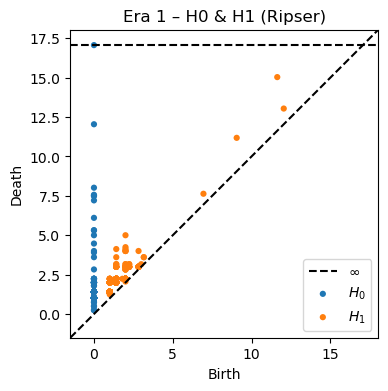

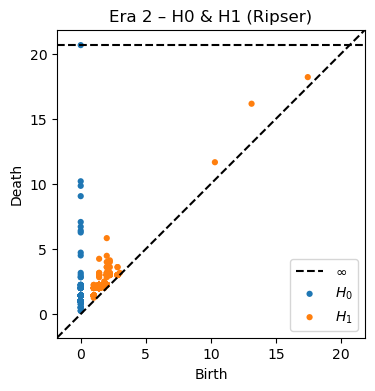

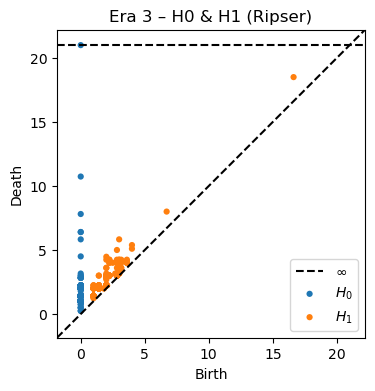

In [64]:
from persim import plot_diagrams
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_diagrams(dgms_era1_ripser, title="Era 1 – H0 & H1 (Ripser)")
plt.show()

plt.figure(figsize=(10,4))
plot_diagrams(dgms_era2_ripser, title="Era 2 – H0 & H1 (Ripser)")
plt.show()

plt.figure(figsize=(10,4))
plot_diagrams(dgms_era3_ripser, title="Era 3 – H0 & H1 (Ripser)")
plt.show()

In [65]:
import numpy as np

tda_features = np.array([
    [0, d12, d13],
    [d12, 0, d23],
    [d13, d23, 0]
])
tda_features

array([[0.        , 1.49470139, 1.70179653],
       [1.49470139, 0.        , 1.51554489],
       [1.70179653, 1.51554489, 0.        ]])

In [66]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(tda_features)

coords

array([[-1.1696449 , -0.63613058],
       [-0.06558037,  1.17604922],
       [ 1.23522528, -0.53991864]])

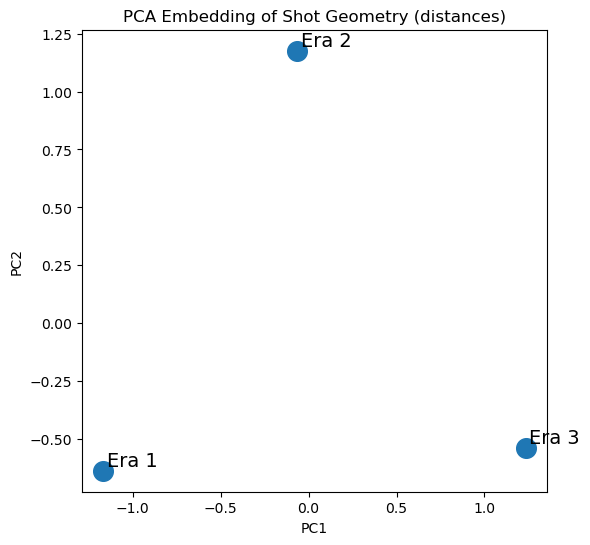

In [68]:
plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=200)

labels = ["Era 1", "Era 2", "Era 3"]
for i, label in enumerate(labels):
    plt.text(coords[i,0] + 0.02, coords[i,1] + 0.02, label, fontsize=14)

plt.title("PCA Embedding of Shot Geometry (distances)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [69]:
import numpy as np
import pandas as pd

nba_all = shots.nba_all.copy()


if "shot_clock" not in nba_all.columns:
    nba_all["shot_clock"] = nba_all["clock_seconds"]

nba_all["shot_clock"] = nba_all["shot_clock"].clip(0,24)

def assign_bucket(sc):
    if sc >= 17:
        return "Transition (17–24s)"
    elif sc >= 7:
        return "Set Offense (7–17s)"
    else:
        return "Desperation (0–7s)"

nba_all["clock_bucket"] = nba_all["shot_clock"].apply(assign_bucket)

nba_all["clock_bucket"].value_counts()

clock_bucket
Transition (17–24s)    2502508
Set Offense (7–17s)     601580
Desperation (0–7s)      481326
Name: count, dtype: int64

In [70]:
X_transition = nba_all[nba_all.clock_bucket=="Transition (17–24s)"][["coordinate_x","coordinate_y"]].to_numpy()
X_setoff = nba_all[nba_all.clock_bucket=="Set Offense (7–17s)"][["coordinate_x","coordinate_y"]].to_numpy()
X_desper = nba_all[nba_all.clock_bucket=="Desperation (0–7s)"][["coordinate_x","coordinate_y"]].to_numpy()

X_transition.shape, X_setoff.shape, X_desper.shape

((2502508, 2), (601580, 2), (481326, 2))

In [71]:
import numpy as np

def subsample(X, n_samples=10000, seed=0):
    np.random.seed(seed)
    if X.shape[0] > n_samples:
        idx = np.random.choice(X.shape[0], size=n_samples, replace=False)
        return X[idx]
    else:
        return X

X_trans_sub = subsample(X_transition, n_samples=8000)
X_set_sub   = subsample(X_setoff,     n_samples=8000)
X_desp_sub  = subsample(X_desper,     n_samples=8000)

X_trans_sub.shape, X_set_sub.shape, X_desp_sub.shape

((8000, 2), (8000, 2), (8000, 2))

In [72]:
dgms_trans = tdb.persistence_ripser(X_trans_sub, maxdim=1)

In [73]:
dgms_set   = tdb.persistence_ripser(X_set_sub,   maxdim=1)

In [74]:
dgms_desp  = tdb.persistence_ripser(X_desp_sub,  maxdim=1)

In [75]:
[d.shape for d in dgms_trans]

[(1805, 2), (1036, 2)]

In [76]:
[d.shape for d in dgms_set]

[(1793, 2), (1021, 2)]

In [77]:
[d.shape for d in dgms_desp]

[(1995, 2), (1107, 2)]

In [78]:
d_trans_set = tdb.diagram_distance(dgms_trans[1], dgms_set[1], metric="bottleneck")
d_set_desp  = tdb.diagram_distance(dgms_set[1],  dgms_desp[1], metric="bottleneck")
d_trans_desp= tdb.diagram_distance(dgms_trans[1], dgms_desp[1], metric="bottleneck")

d_trans_set, d_set_desp, d_trans_desp

(1.0, 2.4913744926452637, 2.4913744926452637)

In [79]:
w_trans_set = tdb.diagram_distance(dgms_trans[1], dgms_set[1], metric="wasserstein")
w_set_desp  = tdb.diagram_distance(dgms_set[1],  dgms_desp[1], metric="wasserstein")
w_trans_desp= tdb.diagram_distance(dgms_trans[1], dgms_desp[1], metric="wasserstein")

w_trans_set, w_set_desp, w_trans_desp

(29.47950538537521, 44.421570121912964, 52.865569001321)

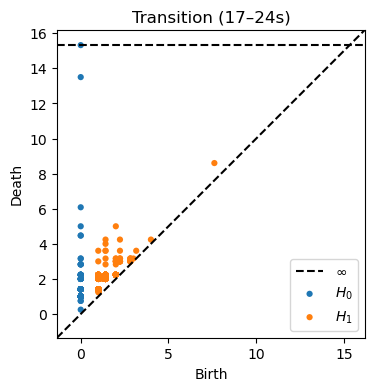

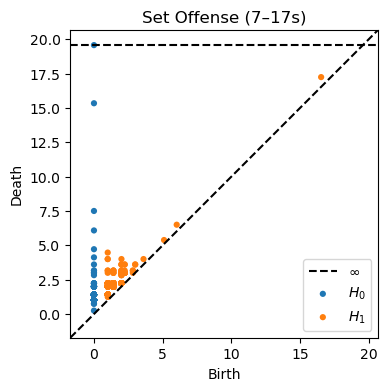

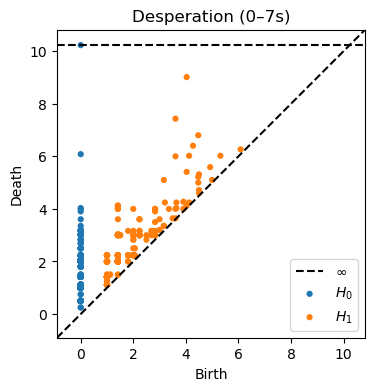

In [80]:
from persim import plot_diagrams
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plot_diagrams(dgms_trans, title="Transition (17–24s)")
plt.show()

plt.figure(figsize=(8,4))
plot_diagrams(dgms_set, title="Set Offense (7–17s)")
plt.show()

plt.figure(figsize=(8,4))
plot_diagrams(dgms_desp, title="Desperation (0–7s)")
plt.show()

In [81]:
import numpy as np

D = np.array([
    [0,            d_trans_set, d_trans_desp],
    [d_trans_set,  0,           d_set_desp ],
    [d_trans_desp, d_set_desp,  0]
])

D

array([[0.        , 1.        , 2.49137449],
       [1.        , 0.        , 2.49137449],
       [2.49137449, 2.49137449, 0.        ]])

In [82]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
coords = mds.fit_transform(D)

coords

/opt/conda/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  Determines the random number generator used to initialize the centers.


array([[ 0.19198884,  0.93603735],
       [ 0.92269075,  0.24832927],
       [-1.11467959, -1.18436662]])

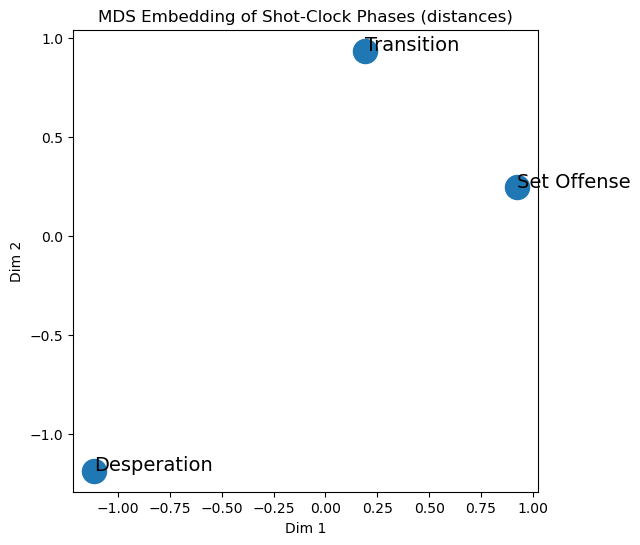

In [95]:
plt.figure(figsize=(6,6))
labels = ["Transition", "Set Offense", "Desperation"]

plt.scatter(coords[:,0], coords[:,1], s=300)

for i, txt in enumerate(labels):
    plt.annotate(txt, (coords[i,0], coords[i,1]), fontsize=14)

plt.title("MDS Embedding of Shot-Clock Phases (distances)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [84]:
print("MBB seasons:", list(mbb.keys())[:20])

sample_season = sorted(mbb.keys())[-1]
print("Sample season:", sample_season)

mbb_sample = mbb[sample_season]
print(mbb_sample.shape)
print(mbb_sample.columns)

mbb_sample.head()

MBB seasons: ['2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Sample season: 2024
(957173, 27)
Index(['game_id', 'game_play_number', 'id', 'sequence_number', 'season',
       'season_type', 'athlete_id_1', 'period_number', 'period_display_value',
       'time', 'clock_display_value', 'clock_minutes', 'clock_seconds', 'half',
       'away_score', 'home_score', 'scoring_play', 'score_value',
       'shooting_play', 'team_id', 'home_team_id', 'home_team_name',
       'away_team_id', 'away_team_name', 'coordinate_x', 'coordinate_y',
       'league'],
      dtype='object')


,game_id,game_play_number,id,sequence_number,season,season_type,athlete_id_1,period_number,period_display_value,time,...,score_value,shooting_play,team_id,home_team_id,home_team_name,away_team_id,away_team_name,coordinate_x,coordinate_y,league
0,401638645,2,4.016386e+17,101806601,2024,3,4600663.0,1,1st Half,19:33,...,2,True,2509,41,UConn,2509,Purdue,-31.75,0.0,MBB
1,401638645,5,4.016386e+17,101808401,2024,3,4917149.0,1,1st Half,19:15,...,3,True,41,41,UConn,2509,Purdue,22.75,18.0,MBB
2,401638645,7,4.016386e+17,101809901,2024,3,4897438.0,1,1st Half,19:00,...,2,True,2509,41,UConn,2509,Purdue,-33.75,4.0,MBB
3,401638645,8,4.016386e+17,101815901,2024,3,4433083.0,1,1st Half,18:40,...,3,True,41,41,UConn,2509,Purdue,28.75,-19.0,MBB
4,401638645,9,4.016386e+17,101818701,2024,3,4432002.0,1,1st Half,18:12,...,2,True,2509,41,UConn,2509,Purdue,-40.75,3.0,MBB


In [85]:
X_mbb_all = pd.concat(
    [mbb[season][["coordinate_x", "coordinate_y"]] for season in mbb.keys()]
).to_numpy()

X_mbb_all.shape

(10272140, 2)

In [86]:
X_mbb_all_clean = X_mbb_all[~np.isnan(X_mbb_all).any(axis=1)]
X_mbb_all_clean.shape

(1408613, 2)

In [87]:
X_mbb_sub = subsample(X_mbb_all_clean, 5000, seed=44)
X_mbb_sub.shape

(5000, 2)

In [88]:
dgms_mbb = tdb.persistence_ripser(X_mbb_sub, maxdim=1)
dgms_mbb

[array([[0.00000000e+00, 5.00000000e-01],
        [0.00000000e+00, 5.00000000e-01],
        [0.00000000e+00, 5.00000000e-01],
        ...,
        [0.00000000e+00, 2.14748352e+08],
        [0.00000000e+00, 2.14748368e+08],
        [0.00000000e+00,            inf]]),
 array([[26.5       , 27.77138901],
        [24.08318901, 25.29822159],
        [ 3.60555124,  4.        ],
        ...,
        [ 1.        ,  1.41421354],
        [ 1.        ,  1.41421354],
        [ 1.        ,  1.41421354]])]

In [89]:
d_nba_mbb = tdb.diagram_distance(dgms_era3_ripser[1], dgms_mbb[1], metric="bottleneck")
w_nba_mbb = tdb.diagram_distance(dgms_era3_ripser[1], dgms_mbb[1], metric="wasserstein")

d_nba_mbb, w_nba_mbb

(1.0, 34.94014200909044)

In [90]:
nba_2024 = nba["2024"].copy()

nba_2024 = nba_2024.dropna(subset=["coordinate_x", "coordinate_y", "athlete_id_1"])

player_clouds = {
    pid: grp[["coordinate_x", "coordinate_y"]].to_numpy()
    for pid, grp in nba_2024.groupby("athlete_id_1")
    if len(grp) >= 300
}

len(player_clouds)

290

In [91]:
dgms_players = {}
for pid, X in player_clouds.items():
    X_sub = subsample(X, n_samples=1000, seed=1)
    dgms = tdb.persistence_ripser(X_sub, maxdim=1)
    dgms_players[pid] = dgms[1]
len(dgms_players)

290

In [92]:
import numpy as np

pids = list(dgms_players.keys())
N = len(pids)

D_players = np.zeros((N, N))

for i in range(N):
    for j in range(i+1, N):
        d = tdb.diagram_distance(dgms_players[pids[i]], dgms_players[pids[j]], metric="bottleneck")
        D_players[i, j] = d
        D_players[j, i] = d

D_players

KeyboardInterrupt: 

In [45]:
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0)
coords = mds.fit_transform(D_players)
coords.shape

/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


(290, 2)

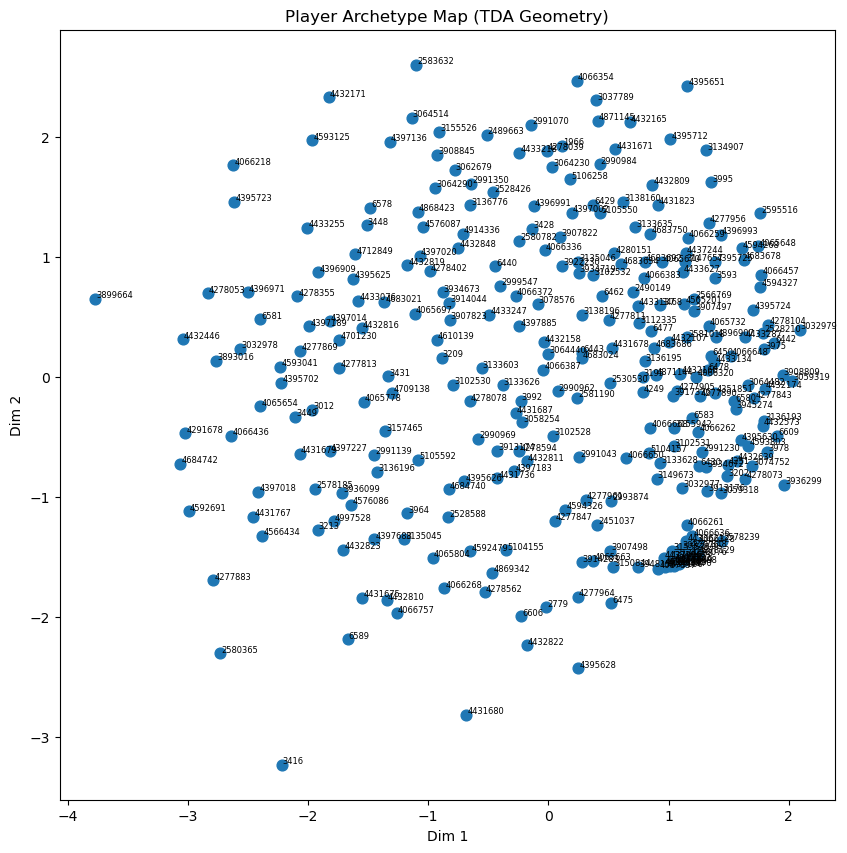

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(coords[:,0], coords[:,1], s=60)

for i, pid in enumerate(pids):
    plt.text(coords[i,0] + 0.01, coords[i,1] + 0.01, str(pid), fontsize=6)

plt.title("Player Archetype Map (TDA Geometry)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()